# Hypothesis Testing in Python 

This notebook introduces hypothesis testing using built-in Python functions so you can focus on what the test means rather than the math behind it.

We’ll explore:

- How hypothesis testing connects to confidence intervals

- How to choose the right test

- How to interpret results for business insights

In [2]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
from statsmodels.stats.proportion import proportions_ztest
from statsmodels.stats.weightstats import ztest
from scipy.stats import poisson
np.random.seed(42)
import pandas as pd


# What Is Hypothesis Testing?

Think of hypothesis testing as a courtroom process:

- Null hypothesis (H₀): “Nothing has changed” → we assume this is true until proven otherwise.

- Alternative hypothesis (H₁): “Something has changed.”

We collect sample data, run a test, and decide whether there’s enough evidence to reject H₀.

## Steps in hypothesis testing:

1. State H₀ and H₁.

2. Choose a significance level (α = 0.05 is common).

3. Run the test → calculate p-value.

4. If p < α, reject H₀.

5. Interpret results in context.

Connection to Confidence Intervals:
If the hypothesized value lies outside your confidence interval → you’d likely reject H₀.

## Case Study: Normal Distribution (Z-Test)

### Scenario:
You work in a factory producing light bulbs. The average lifetime is expected to be 1000 hours and the standard deviation is 100

You take a sample of 50 bulbs and want to test if the actual mean lifetime is different from 1000 hours.

In [3]:
# Read the data
df_bulbs =pd.read_csv("data/bulbs.csv")


In [4]:
df_bulbs.head()

,lifespan
0,925.917823
1,970.209714
2,858.354482
3,884.223402
4,1094.386749


### Perform the Z test as the population parameters are known

In [5]:
z_stat, p_value = ztest(df_bulbs["lifespan"], value=1000, alternative="two-sided")
print(f"Z-Statistic: {z_stat:.2f}")
print(f"P-Value: {p_value:.4f}")


Z-Statistic: -0.26
P-Value: 0.7919


### Decision Making

In [6]:
alpha = 0.05
if p_value < alpha:
    print("Reject H₀: The average lifetime is significantly different from 1000 hours.")
else:
    print("Fail to reject H₀: No significant difference from 1000 hours.")


Fail to reject H₀: No significant difference from 1000 hours.


### Plotting for visual confirmation of the Means


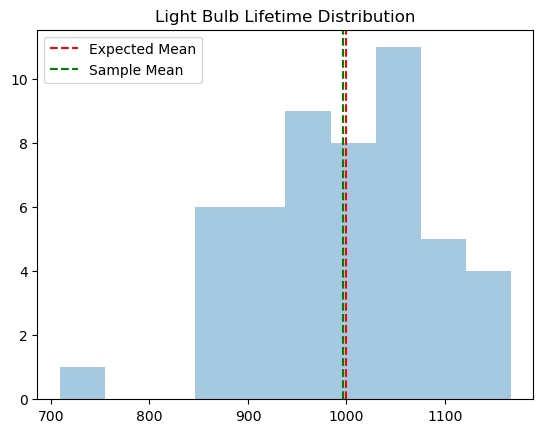

In [7]:
plt.hist(df_bulbs["lifespan"], bins=10, color="#7FB3D5", alpha=0.7)
plt.axvline(1000, color='red', linestyle='--', label='Expected Mean')
plt.axvline(df_bulbs['lifespan'].mean(), color='green', linestyle='--', label='Sample Mean')
plt.title("Light Bulb Lifetime Distribution")
plt.legend()
plt.show()


# One-Tailed vs Two-Tailed Tests – Light Bulb Scenario

Objective: Learn how hypothesis framing (one-tailed vs two-tailed) affects testing using simple functions.

Scenario:
We’re testing the mean lifetime of light bulbs. Population mean is 1000 hours. We take a sample of 50 bulbs. Note here we do not know the standard deviation hence we will use the `ttest_1samp`

In [8]:
# Using t-test for sample vs population mean
t_stat, p_value_two = stats.ttest_1samp(df_bulbs['lifespan'], popmean=1000, alternative='two-sided')

print(f"Two-tailed t-statistic: {t_stat:.2f}, p-value: {p_value_two:.3f}")


Two-tailed t-statistic: -0.26, p-value: 0.793


In [9]:
#Step 2: One-Tailed Test (Testing if bulbs last longer than expected)

#Hypotheses:

#H₀: μ = 1000

#H₁: μ > 1000

t_stat, p_value_one = stats.ttest_1samp(df_bulbs["lifespan"], popmean=1000, alternative='greater')

print(f"One-tailed t-statistic: {t_stat:.2f}, p-value: {p_value_one:.3f}")

One-tailed t-statistic: -0.26, p-value: 0.604


## Importance of checking the "Sidedness" of the test!

The difference could lead to a null hypothesis being rejected!


In [ ]:
np.random.seed(101)

# Simulate a sample slightly above the population mean
sample = np.random.normal(loc=1010, scale=100, size=50)  # mean 1010, slightly above 1000
population_mean = 1000

# Two-tailed test
t_stat_two, p_value_two = stats.ttest_1samp(sample, popmean=population_mean, alternative='two-sided')

# One-tailed test (greater)
t_stat_one, p_value_one = stats.ttest_1samp(sample, popmean=population_mean, alternative='greater')

print(f"Two-tailed t-statistic: {t_stat_two:.2f}, p-value: {p_value_two:.3f}")
print(f"One-tailed t-statistic: {t_stat_one:.2f}, p-value: {p_value_one:.3f}")


Two-tailed t-statistic: 2.51, p-value: 0.015
One-tailed t-statistic: 2.51, p-value: 0.008


# Summary Table

| Test Type               | When to Use                 | Example           | Python Function       |
| ----------------------- | --------------------------- | ----------------- | --------------------- |
| **Z-Test (Mean)**       | Continuous data, known SD   | Bulb lifetime     | `ztest()`             |
| **t-Test (Mean)**       | Continuous data, unknown SD | Small sample mean | `stats.ttest_1samp()` |




## Key Takeaways

Hypothesis testing helps determine whether your sample provides enough evidence to claim a real difference.

- A low p-value (< 0.05) → reject H₀ → “something is likely different.”

- Confidence intervals and hypothesis tests tell similar stories from different angles.

- Always interpret results in context — statistical significance ≠ business significance.